In [ ]:
    # Decision Tree Assignment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
df=pd.read_csv('bank.csv')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [6]:
df.corr(numeric_only=True)

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


In [7]:
# Section 1: Theoretical Questions

In [ ]:
Question1:- What is a Decision Tree? Explain its structure(Root, Nodes,Leaves) with a real-life example.

In [ ]:
Answer:- A Decision Tree is a supervised ML algorithm that splits data into branches like a
         tree to make decisions.

            Structure
         (i) Root:- Top node ,starts the decision . Example: "Is Age  > 30?"

         (ii) Nodes/ Internal Nodes: Points where data splits based on a condition. Example: " Is Balance > 1000?"

         (iii) Leaves/ Leaf Nodes:- Final nodes with decision / outcome. Example ." Predict= Yes" or "Predict=" No"


     Real-Life example:- Deciding "will customer take term deposit?"

     Root:- Age>30-> Yes-> Node: Balance > 2000?-> Yes ->Leaf: Predict Yes

In [ ]:
# Question2:- Difference between Gini impurity and Entropy.
  Which one is used by default in Scikit-learn and why?  

In [ ]:
# Answer2:-                Gini And Entropy
           # Why to use it?

           # In Decision Tree every time we have to decide which column will get split.
           # So Gini and Entropy is a scale to  helps us decide it.


         # GINI IMPURITY:- 
         # Definition :- Gini Impurity measures how often a randomly chosen element would be 
        # incorrectly labeled if it was randomly labeled according to the distribution of labels in the subest.

        Simple Expalanation of formula:-

It explains: " What is the probability of misclassifying a random point"

            Example:- If a node has 70% and 305 No:
            Gini= 1[0.7 square + 0.3 square]=1- 0.58= 4.2

            Range 0 to 0.5

        # Gini = 0 -> Pure node, all samples are some 
        # Class= Best split
        # Gini = 0.5 ->50-50 mix = Worst impurity

# 2:- Entropy - Definition
# Definition:- Entropy measures the amount of disorder or uncertanity in a dataset.Higher entropy = more randomness.
Formula : 
where pi = probability of class i

Simple Explanation:-
It answers:" How much confusion/impurity is in this group?

    Example :- same 70% yes, 30% No
Entropy=

Range 0 to 1 

Entropy = 0 -> Pure node, no confusion
Entropy=1 -> 50-50 mix= Maximum confusion

# 3 Which one is default in Scikit-learn and why?
Default Gini->
DecisionTreeClassifier(criterion='gini')

why Gini is default:-

1:- Computationally faster:- No algorithm calculation needed, only squares. Saves time on large dataets.

2:- Similar performance:- Both Gini and Entropy usually give the same tree structure and accuracy.Difference is <2%.

3:- Slightly less overfitting:- Gini tends to create slightly more balanced trees.

    When to use Entropy?

 Use criterian='entropy' when you want the tree to be more sensitive to small changes. It uses Information
  Gain and sometimes gives a slightly better tree, but its slower.

      Key difference in one line:-

Gini='Chance of mistake',Entropy = 'Amount of confusion'



In [ ]:
# Question3:- What is overfitting in Decision Trees?
How can we detect it using training  and testing accuracy ?

In [ ]:
Answer:- Overfitting :- Model learns training data too well including noise. It performs 99% on train but 70% on test.
     Tree becomes too deep and complex.

         Detection using accuracy:

         If Training accuracy >> Testing accuracy, then overfitting.

        Example:- Train99%, Test=82% -> Overfitting.

    If both low, like Train=70%, Test=68% -> Underfitting

In [ ]:
# Question4:- Explain Pruning in Decision Trees.
What is the difference between Pre-pruning and post-pruning?


In [ ]:
Answer:- Pruning = Cutting branches to reduce overfitting and make tree simpler.

    Pre-pruning: Stop tree growth early using parameters like max_depth=5,
    min_samples_split=20." Stop before overfitting".

        Post-Pruning:- Grow full tree first, then cut unnecessary branches later."Grow full,then cut".

In [ ]:
# Question5:- What is feature importance?
How can it help businesses in decision-making?


In [ ]:
Answer:- Features Importance = Score showing which columns/features affect prediction most.Value 0 to 1. Higher = more important

      For Business :- Bank can focus on top features. If duration and poutcome are top features.
                      If duration and poutcome are top,bank should train call agents to keep call
                      duration long and target customers who did not subscribe before but were contacted.

In [ ]:
 # SECTION 2:-Practical Questions(Hands-on using your dataset)


In [ ]:
Question6:- Data Understanding
            * Load the dataset
            * Display first 5 rows
            * Check:
            * Shape
            * Data types
            * Column names
 Interpret:

* What types of variables are present?


In [8]:
# Answer:-
        # Load the dataset

df=pd.read_csv('bank.csv')

# Display first 5 rows
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
# Shape of data

df.shape

(11162, 17)

In [7]:
# Datatypes

df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

In [8]:
# Columns in Dataframe

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [ ]:
# Interpretation:- Dataset has (11162 rows, 17 columns). Variables are of 2 types Numerical like age, balance,duration
                 # and categorical like job, marital,education,y. Traget column is y with values yes/no.

In [ ]:
Question7:- 
          Data Cleaning
          Check for missing values
          Handel missing values (if any)
          Check for duplicates

 Interpret:
            Is the dataset clean? What issues did you find?

In [9]:
# Answer:-  Check for missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [ ]:
#  Clearly there is no any missing values.

In [10]:
# Check duplicated
df.duplicated().sum()

np.int64(0)

In [ ]:
# Interpretation
# As it is showing there is no any duplicate value in the dataset.Also there were no any missing values found 
# So dataset is clean , therefore no handeling needed.

In [ ]:
Question8:-
  Data Preprocessing
* Convert categorical variables into numerical
* Mention which encoding method you used

 Interpret:
            Why is encoding necessary for Decision Trees?

In [11]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [ ]:
# Convert categorical variables into numerical

In [15]:
# Target to 0/1
df['deposit']=df['deposit'].str.strip().str.lower().map({'no':0,'yes':1})

In [15]:
df['deposit']

0        1
1        1
2        1
3        1
4        1
        ..
11157    0
11158    0
11159    0
11160    0
11161    0
Name: deposit, Length: 11162, dtype: int64

In [16]:
# now we will practice One-Hot-Encoding on categorical data.

categorical_cols=['job','marital','education','default','housing','loan','contact','month','poutcome']

df=pd.get_dummies(df,columns=categorical_cols,drop_first=True)

In [17]:
df

,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,0,True,False,...,False,False,False,False,False,False,False,False,False,True
11158,39,733,16,83,4,-1,0,0,False,False,...,False,True,False,False,False,False,False,False,False,True
11159,32,29,19,156,2,-1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,True
11160,43,0,8,9,2,172,5,0,False,False,...,False,False,False,True,False,False,False,False,False,False


In [18]:
# Now we will convert true/false to 0/1 that mean categorical into int.

df=df.astype(int)

In [19]:
df

,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
1,56,45,5,1467,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,41,1270,5,1389,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
3,55,2476,5,579,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
4,54,184,5,673,2,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
11158,39,733,16,83,4,-1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
11159,32,29,19,156,2,-1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
11160,43,0,8,9,2,172,5,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [20]:
# Now we will chcek after performing one-hot-encoding how many columns have been added to columns

df.shape

(11162, 43)

In [21]:
#  Mention which encoding method you used

# Encoding Method:- One-Hot-Method +Binary Mapping

# Interpretation:- Decision Tree only understands numerical data so we have to convert the data into categorical to numerical which is 0/1


In [22]:
# Question9:- Feature Selection and Splitting- Step
# Seperate:
# Features(X)
# Target(y)
# Perform train-test split(80-20)

# Interpretation:- Why is train-test split important?

# Answer:-

from sklearn.model_selection import train_test_split
X=df.drop('deposit',axis=1) # Features
y= df['deposit'] # Target

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print('Train_Test',X_train.shape,'Test shape', X_test.shape)

Train_Test (8929, 42) Test shape (2233, 42)


In [ ]:
#Interpretation:-  to train model 80-20 split  + for test we get different different data otherwise model will learn each and every detail 
# of data and it will end up giving problem of overfitting.

In [ ]:
# Question10:- Model Building
# Train a Decision Tree Classifier
# Use:
# criterian='gini'
# max_depth=5
# Interpret:- What does max_depth control?

In [23]:
# Answer:- 
from  sklearn.tree import DecisionTreeClassifier

model= DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)

model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Interpretation:- max_depth=5 means tree will be 5 level deep.
   # More deep= Overfitting.gini is default,Gini < It is fast in doing Entropy.
    

In [ ]:
# Question11:- Model Evaluation
# Perform:
# Accuracy score
# Confusion Matrix
# Classification Report

# Interpret (MUST):
# Is the model performing well?
# Explain precision and Recall
# Any class imbalance issue?

In [24]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
y_pred=model.predict(X_test)

print('Accuracy',accuracy_score(y_test,y_pred))
print('Confusion Report',classification_report(y_test,y_pred))
print('Classification Report', classification_report(y_test,y_pred))

Accuracy 0.7948947604120018
Confusion Report               precision    recall  f1-score   support

           0       0.81      0.79      0.80      1166
           1       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233

Classification Report               precision    recall  f1-score   support

           0       0.81      0.79      0.80      1166
           1       0.78      0.80      0.79      1067

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.79      0.79      2233



In [ ]:
# Interpretation MUST:-

# Precision:- The yes that we have predicted,how many of them were right.
# Recall :- Exactly how many many yes were there and from them how many its has predicted well.
# Class Imbalance:- yes is only 11% . Accuracy could be 90% but model is useless.

In [ ]:
# Question12:- Overfitting check 
# Calculate:
# Training accuracy
# Testing accuracy

# Interpret:- Is the model overfitting or underfitting?

In [25]:
# Answer:- 
train_acc=model.score(X_train,y_train)
test_acc=model.score(X_test,y_test)


In [26]:
print(f'Train Accuracy:{train_acc:.3f}')
print(f'Test Accuracy:{test_acc:.3f}')

Train Accuracy:0.811
Test Accuracy:0.795


In [ ]:
# Interpretation:- Train 81% + Test 79% =Overfitting
# train = test =Good

In [ ]:
# Question13:- Pruning Experiment
# Train-another model with:
# max_depth=3
# min_sample_split=20

# Interpret:
# Compare performance with previous model 
# Which one is the better and why?

In [27]:
# New model with max_depth=3+ min_sample_split=20
model_pruned=DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)
model_pruned.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
# Comapre the both models accuracy.

train_acc_pruned=model_pruned.score(X_train,y_train)
test_acc_pruned=model_pruned.score(X_test,y_test)

print('Pruned Model')
print(f'Train Accuracy:{train_acc_pruned:.3f}')
print(f'Test Accuracy:{test_acc_pruned:.3f}')
print(f'Old Moel Test Acc:{test_acc:.3f}')

Pruned Model
Train Accuracy:0.782
Test Accuracy:0.769
Old Moel Test Acc:0.795


In [ ]:
Interpretation:-

 max_depth=3 = tree is only of 3 level
min_samples_split=20=20 less than data node will not split.

    ii) Pruned Model test accuracy if is better than the privious model data or equal to it than the model is better.
        Simple model= less overfitting

In [ ]:
# Question14:-  Feature Importance
# Extract top 5 important features
# Plot features importance graph

# Interpret:-
# which features influence prediction the most?

In [29]:
import matplotlib.pyplot as plt

# we will find the feature importance

importance= model.feature_importances_
feat_names= X.columns



In [30]:
# top 5 features
feat_imp= pd.Series(importance,index=feat_names).sort_values(ascending=False)
print('Top 5 importance features', feat_imp.head(5))

Top 5 importance features duration            0.605731
poutcome_success    0.156779
contact_unknown     0.143572
housing_yes         0.036242
month_mar           0.032596
dtype: float64


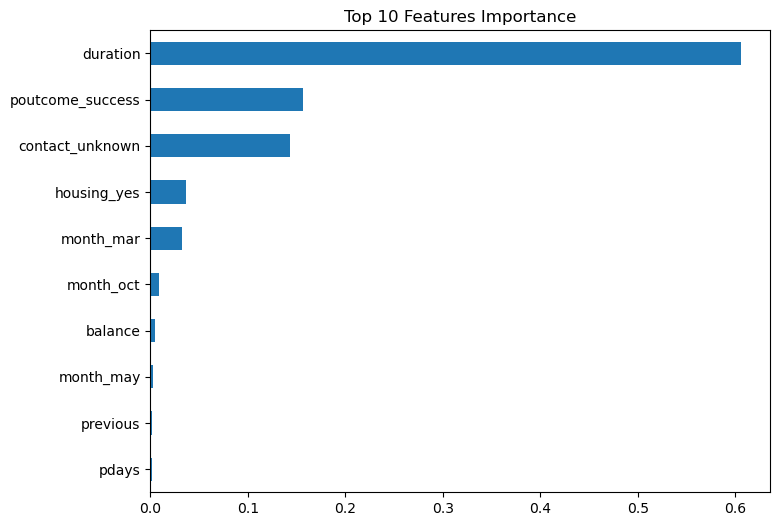

In [31]:
# Plotting
feat_imp.head(10).plot(kind='barh',figsize=(8,6))
plt.title('Top 10 Features Importance')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Interpretation:- Duration,poutcome_success,contact unknown are the top most features.

In [ ]:
# Question15:- Business Insights
# Based on your model:
# Which type of cutomers are more likely to say 'yes'?
# What strategy should a bank us

<Axes: xlabel='duration', ylabel='Count'>

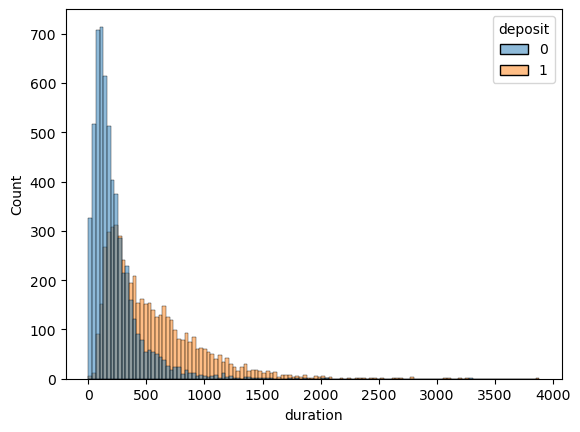

In [43]:
sns.histplot(x='duration',hue='deposit',data=df)

In [ ]:
# Answer15:- 
# Which customer tell yes for deposit = those who took call duration more than 500 seconds,
# those who got the call within 30 days and those who have higher education.

# Bank's Strategy
# Make long calls make customer understand. Call again within 2-3 days.
# When interest rate is  low than only run the capaign.

In [32]:
df

,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
1,56,45,5,1467,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
2,41,1270,5,1389,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
3,55,2476,5,579,1,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
4,54,184,5,673,2,-1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
11158,39,733,16,83,4,-1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
11159,32,29,19,156,2,-1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
11160,43,0,8,9,2,172,5,0,0,0,...,0,0,0,1,0,0,0,0,0,0
